In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc


In [12]:
# Load the phenotype data
catalog_data = pd.read_csv('/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/all_proteins_freq_details_proximity_aaindex_llr.csv')

In [13]:
catalog_data.shape

(6172, 14)

In [14]:
catalog_data = catalog_data.drop_duplicates()

In [15]:
print(catalog_data.shape)

(6172, 14)


In [16]:
catalog_data['confidence'].value_counts()

confidence
3) Uncertain significance     5699
2) Assoc w R - Interim         225
1) Assoc w R                   186
5) Not assoc w R                41
4) Not assoc w R - Interim      21
Name: count, dtype: int64

In [17]:
catalog_data.columns

Index(['gene', 'one_letter_mutation', 'drug', 'confidence', 'delta_z',
       'frequency', 'phenotype', 'position', 'Proximity_to_R_Conferring',
       'Nearest_Mutation_Index', 'aa_index_dist', 'Wildtype_AA', 'Mutated_AA',
       'llr_score'],
      dtype='object')

In [18]:
# Count the number of NaN rows in the 'Proximity_to_R_Conferring' column for each unique gene
nan_frequency_count = catalog_data.groupby('gene')['llr_score'].apply(lambda x: x.isna().sum())

# Display the result
print(nan_frequency_count)


gene
Rv0678    0
atpE      0
ddn       0
embB      0
ethA      0
fgd1      0
gid       0
gyrA      0
gyrB      0
inhA      0
katG      0
pepQ      0
pncA      0
rplC      0
rpoB      0
rpsL      0
tlyA      0
Name: llr_score, dtype: int64


In [19]:
# Filter out category 3 entries
train_data = catalog_data[catalog_data['confidence'] != "3) Uncertain significance"]


In [27]:
# Specify the gene of interest
gene_of_interest = 'rpoB'  # Replace with the gene you're interested in

# Filter the DataFrame for the specific gene
gene_data = catalog_data[catalog_data['gene'] == gene_of_interest]

# Finding the index of the maximum delta_z within the filtered gene data
max_delta_z_index = gene_data['delta_z'].idxmax()

# Finding the index of the maximum llr_score within the filtered gene data
max_llr_index = gene_data['llr_score'].idxmax()

# Printing the row with the maximum delta_z for the specified gene
print(f"Row with the highest delta_z for {gene_of_interest}:")
print(catalog_data.loc[max_delta_z_index])

# Printing the row with the maximum llr_score for the specified gene
print(f"\nRow with the highest llr_score for {gene_of_interest}:")
print(catalog_data.loc[max_llr_index])


Row with the highest delta_z for rpoB:
gene                                              rpoB
one_letter_mutation                              G693V
drug                                        Rifampicin
confidence                   3) Uncertain significance
delta_z                                       0.166564
frequency                                          0.0
phenotype                                      Unknown
position                                           693
Proximity_to_R_Conferring                    14.610286
Nearest_Mutation_Index                           443.0
aa_index_dist                                42.973849
Wildtype_AA                                          G
Mutated_AA                                           V
llr_score                                    -0.234477
Name: 351, dtype: object

Row with the highest llr_score for rpoB:
gene                                              rpoB
one_letter_mutation                              G642S
drug          

In [28]:

# List of numeric columns to use as features
numeric_columns = ['delta_z', 'frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score']

# Fill NaN values in the features with 0 or any suitable value
train_data[numeric_columns] = train_data[numeric_columns].fillna(0)

/tmp/ipykernel_3935374/3655951126.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[numeric_columns] = train_data[numeric_columns].fillna(0)


In [29]:
# Extract the feature matrix and target vector
X_train = train_data[numeric_columns]
y_train = train_data['confidence']

In [30]:
print(X_train.shape, y_train.shape)

(473, 5) (473,)


In [31]:
# Convert the target variable to numeric labels
y_train = y_train.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 2,
    "4) Not assoc w R - Interim": 4,
    "5) Not assoc w R": 5
})


In [32]:
y_train.value_counts()

confidence
2    225
1    186
5     41
4     21
Name: count, dtype: int64

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [34]:
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_train, test_size=0.3, random_state=42)


In [43]:
X_test_split.shape

(142, 5)

In [35]:
# Train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)


In [36]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))


Confusion Matrix:
[[37 12  0  0]
 [25 51  1  2]
 [ 0  2  1  3]
 [ 0  0  0  8]]

Classification Report:
              precision    recall  f1-score   support

           1       0.60      0.76      0.67        49
           2       0.78      0.65      0.71        79
           4       0.50      0.17      0.25         6
           5       0.62      1.00      0.76         8

    accuracy                           0.68       142
   macro avg       0.62      0.64      0.60       142
weighted avg       0.70      0.68      0.68       142


Accuracy Score:
0.6830985915492958


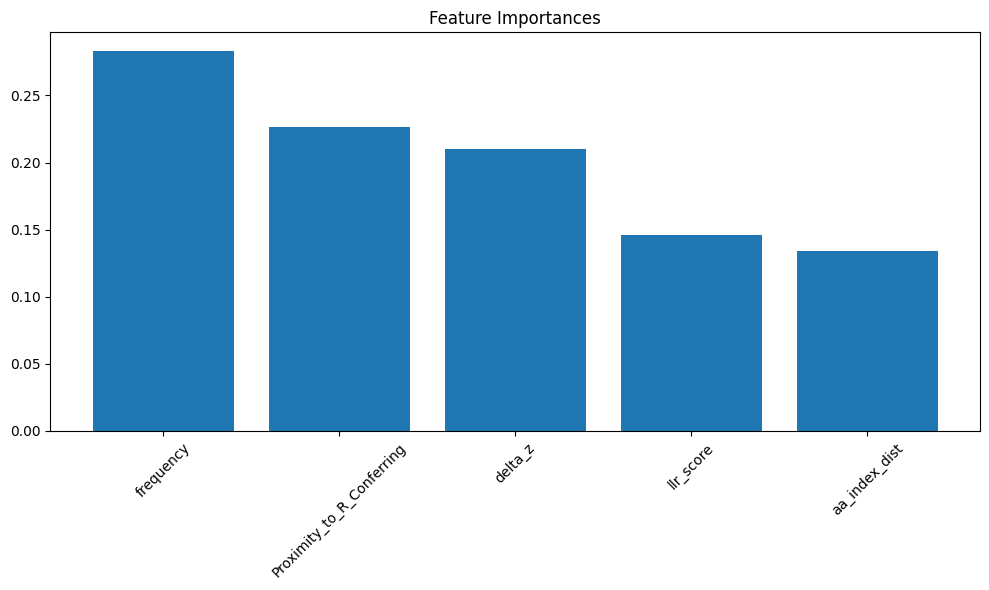

In [37]:
# Feature Importance
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [numeric_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

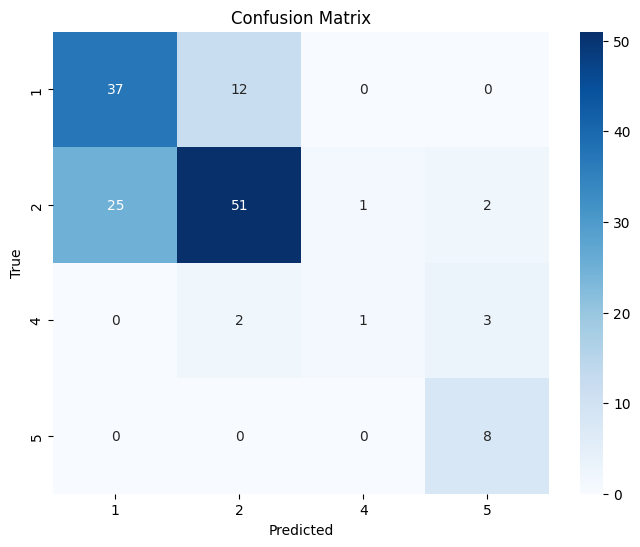

In [38]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test_split, y_pred_split)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 4, 5], yticklabels=[1, 2, 4, 5])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [39]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(X_test_split)
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}



In [40]:
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])


Unique classes: [1, 2, 4, 5]
Number of prediction columns in y_prob_split: 4


In [41]:
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    

# This approach ensures you are accessing the correct column for each class


In [42]:
for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])

1 0.848035988588984
2 0.813240908177617
4 0.9638480392156863
5 0.9916044776119404


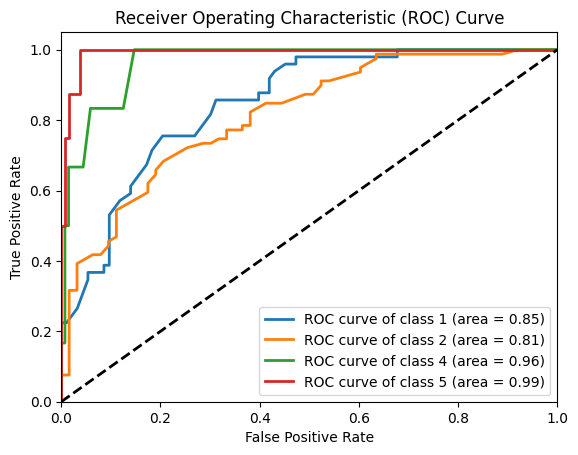

In [28]:

plt.figure()
for i in unique_classes:
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [30]:
# Predict the confidence categories for the entries labeled as category 3
category_3_data =catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
X_category_3 = category_3_data[numeric_columns]

# Make predictions for category 3 data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)
catalog_data.loc[catalog_data['confidence'] == "3) Uncertain significance", 'predicted_confidence'] = category_3_data['predicted_confidence']

# # Save the updated phenotype data with predictions
# phenotype_data.to_csv('/path/to/updated_phenotype_data.csv', index=False)

# print("Predictions for category 3 data have been saved to 'updated_phenotype_data.csv'.")

/tmp/ipykernel_2792894/3953226937.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/tmp/ipykernel_2792894/3953226937.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data['predicted_confidence'] = rf_classifier.

In [31]:
catalog_data['predicted_confidence'].value_counts()

predicted_confidence
1.0    3663
5.0    1656
2.0     378
4.0       2
Name: count, dtype: int64

## with sixth feature thermostability

In [44]:
rpoB_data=pd.read_csv('/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/rpob_thermostability.csv')
pncA_data=pd.read_csv('/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/pncA_thermostability.csv')

In [45]:
# Concatenate the two DataFrames
combined_data = pd.concat([rpoB_data, pncA_data], axis=0, ignore_index=True)

In [46]:
combined_data =combined_data.drop_duplicates()
print(combined_data.shape)
combined_data['confidence'].value_counts()

(792, 16)


confidence
3) Uncertain significance     680
2) Assoc w R - Interim         82
1) Assoc w R                   24
5) Not assoc w R                5
4) Not assoc w R - Interim      1
Name: count, dtype: int64

In [47]:
# Filter out category 3 entries
train_data = combined_data[combined_data['confidence'] != "3) Uncertain significance"]

In [48]:

# List of numeric columns to use as features
numeric_columns = ['delta_z', 'frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']

# Fill NaN values in the features with 0 or any suitable value
train_data[numeric_columns] = train_data[numeric_columns].fillna(0)

/tmp/ipykernel_3935374/3909194332.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[numeric_columns] = train_data[numeric_columns].fillna(0)


In [49]:
# Extract the feature matrix and target vector
X_train = train_data[numeric_columns]
y_train = train_data['confidence']
print(X_train.shape, y_train.shape)

(112, 6) (112,)


In [50]:
# Convert the target variable to numeric labels
y_train = y_train.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 2,
    "4) Not assoc w R - Interim": 4,
    "5) Not assoc w R": 5
})


In [51]:
y_train.value_counts()

confidence
2    82
1    24
5     5
4     1
Name: count, dtype: int64

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_train, test_size=0.3, random_state=42)
# Train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))

Confusion Matrix:
[[ 3  6]
 [ 1 24]]

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.33      0.46         9
           2       0.80      0.96      0.87        25

    accuracy                           0.79        34
   macro avg       0.78      0.65      0.67        34
weighted avg       0.79      0.79      0.76        34


Accuracy Score:
0.7941176470588235


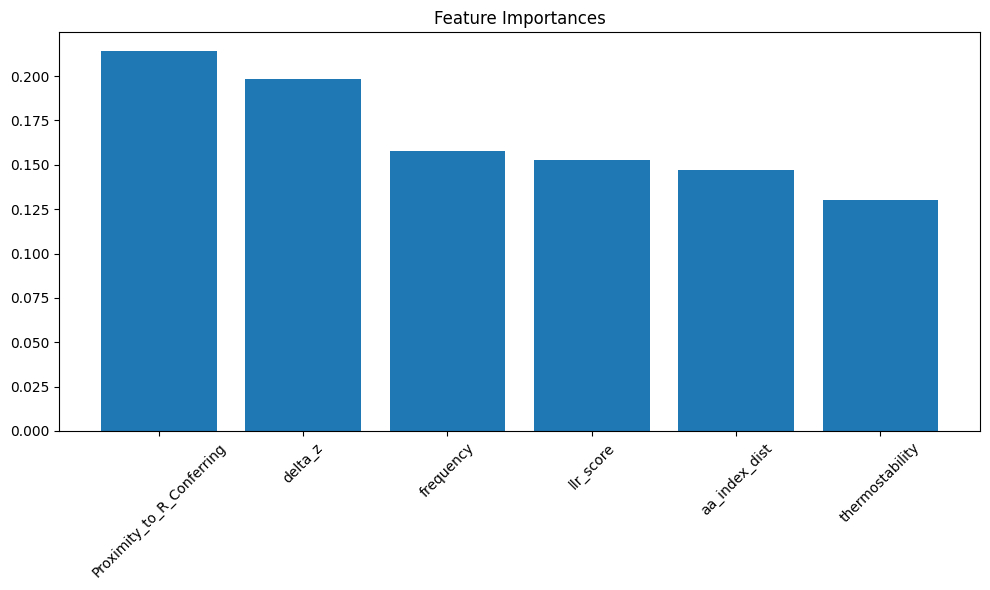

In [53]:
# Feature Importance
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [numeric_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

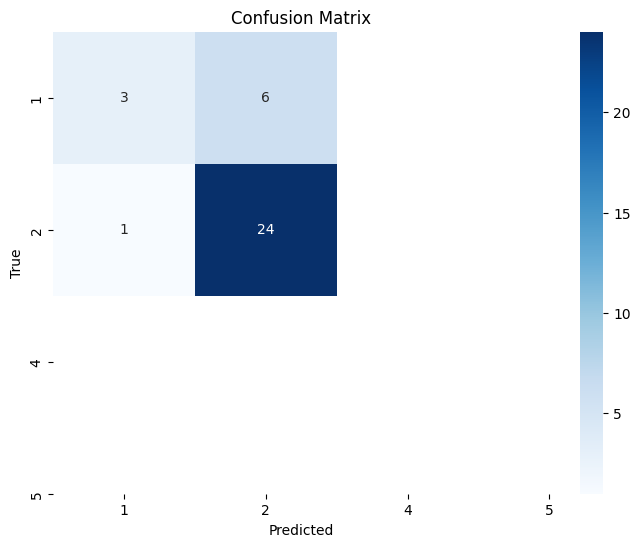

In [54]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test_split, y_pred_split)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 4, 5], yticklabels=[1, 2, 4, 5])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [55]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(X_test_split)
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])

# This approach ensures you are accessing the correct column for each class

Unique classes: [1, 2, 4, 5]
Number of prediction columns in y_prob_split: 4
1 0.8933333333333333
2 0.86
4 nan
5 nan


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


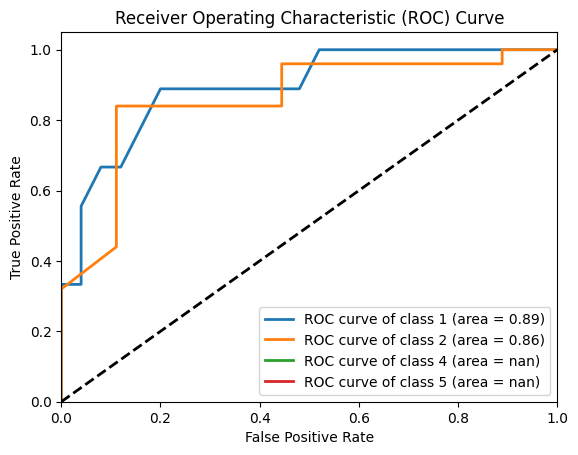

In [43]:

plt.figure()
for i in unique_classes:
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [44]:
# Predict the confidence categories for the entries labeled as category 3
category_3_data =combined_data[combined_data['confidence'] == "3) Uncertain significance"]
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
X_category_3 = category_3_data[numeric_columns]

# Make predictions for category 3 data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)
combined_data.loc[combined_data['confidence'] == "3) Uncertain significance", 'predicted_confidence'] = category_3_data['predicted_confidence']

/tmp/ipykernel_2792894/1694680787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/tmp/ipykernel_2792894/1694680787.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data['predicted_confidence'] = rf_classifier.

In [45]:
combined_data['predicted_confidence'].value_counts()

predicted_confidence
2.0    392
1.0    233
5.0     53
4.0      2
Name: count, dtype: int64

## weighted sampling

In [75]:
import pandas as pd

# Calculate the frequency of each class in the 'confidence' column
confidence_counts = combined_data['confidence'].value_counts()

# Calculate class weights (inversely proportional to frequency)
class_weights = confidence_counts.sum() / confidence_counts
print("Class Weights:\n", class_weights)

# Filter out the '3) Uncertain significance' class
filtered_data = combined_data[combined_data['confidence'] != '3) Uncertain significance']

# Merge the weights back into the filtered DataFrame based on 'confidence' class
filtered_data['weights'] = filtered_data['confidence'].map(class_weights)

# Perform weighted sampling using pandas' sample function
resampled_df = filtered_data.sample(n=len(filtered_data),
                                    replace=True,                         # Sample with replacement
                                    weights=filtered_data['weights'],     # Use calculated weights
                                    random_state=42)                      # Set a seed for reproducibility

# Check the distribution after resampling
print("Resampled confidence distribution:\n", resampled_df['confidence'].value_counts())


Class Weights:
 confidence
3) Uncertain significance       1.164706
2) Assoc w R - Interim          9.658537
1) Assoc w R                   33.000000
5) Not assoc w R              158.400000
4) Not assoc w R - Interim    792.000000
Name: count, dtype: float64
Resampled confidence distribution:
 confidence
4) Not assoc w R - Interim    34
5) Not assoc w R              28
1) Assoc w R                  26
2) Assoc w R - Interim        24
Name: count, dtype: int64


/tmp/ipykernel_3935374/3657394645.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['weights'] = filtered_data['confidence'].map(class_weights)


In [76]:
# Filter out category 3 entries
train_data = resampled_df[resampled_df['confidence'] != "3) Uncertain significance"]

# List of numeric columns to use as features
numeric_columns = ['delta_z', 'frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']

# Fill NaN values in the features with 0 or any suitable value
train_data[numeric_columns] = train_data[numeric_columns].fillna(0)

# Extract the feature matrix and target vector
X_train = train_data[numeric_columns]
y_train = train_data['confidence']
print(X_train.shape, y_train.shape)

(112, 6) (112,)


In [77]:
# Convert the target variable to numeric labels
y_train = y_train.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 2,
    "4) Not assoc w R - Interim": 4,
    "5) Not assoc w R": 5
})


In [88]:
y_train.value_counts()

confidence
4    34
5    28
1    26
2    24
Name: count, dtype: int64

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_train, test_size=0.3, random_state=42)
# Train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))

Confusion Matrix:
[[ 5  4  0  0]
 [ 0  6  0  0]
 [ 0  0 12  0]
 [ 0  0  0  7]]

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.56      0.71         9
           2       0.60      1.00      0.75         6
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00         7

    accuracy                           0.88        34
   macro avg       0.90      0.89      0.87        34
weighted avg       0.93      0.88      0.88        34


Accuracy Score:
0.8823529411764706


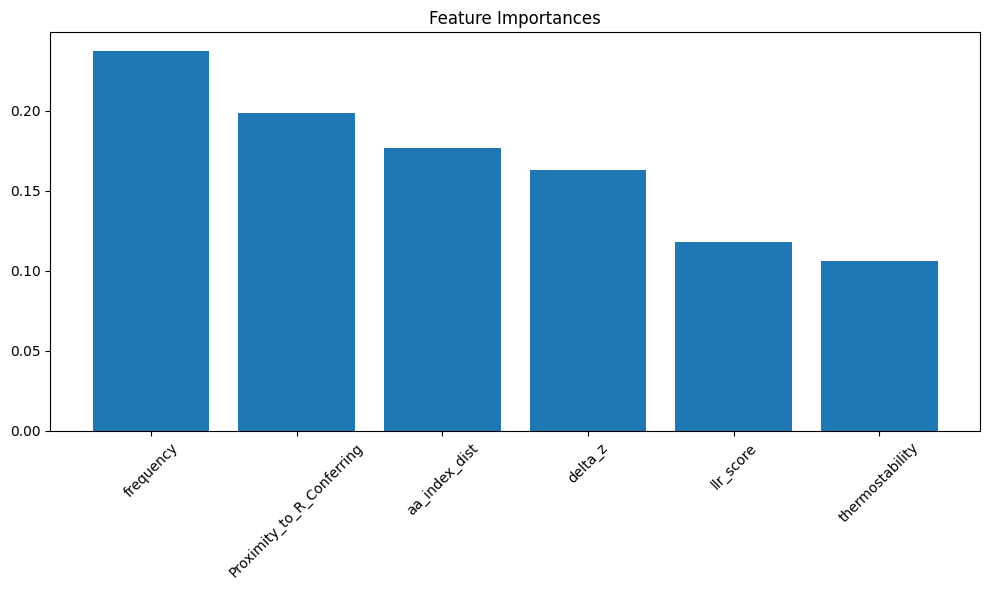

In [79]:
# Feature Importance
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [numeric_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

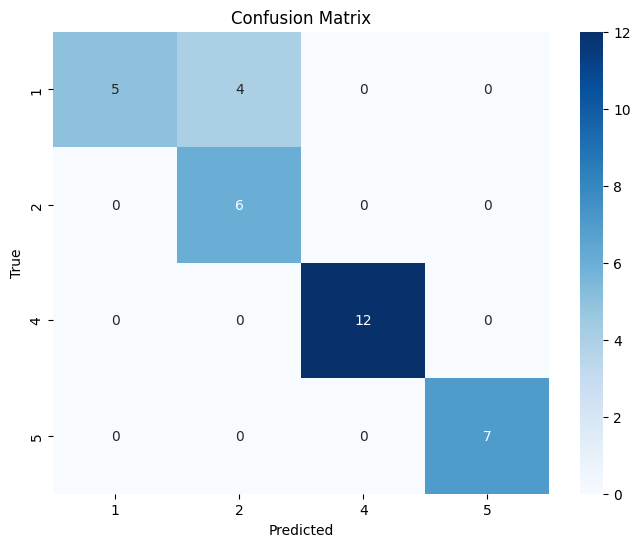

In [80]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test_split, y_pred_split)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 4, 5], yticklabels=[1, 2, 4, 5])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [81]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(X_test_split)
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])

# This approach ensures you are accessing the correct column for each class

Unique classes: [1, 2, 4, 5]
Number of prediction columns in y_prob_split: 4
1 0.9555555555555555
2 0.9285714285714285
4 1.0
5 1.0


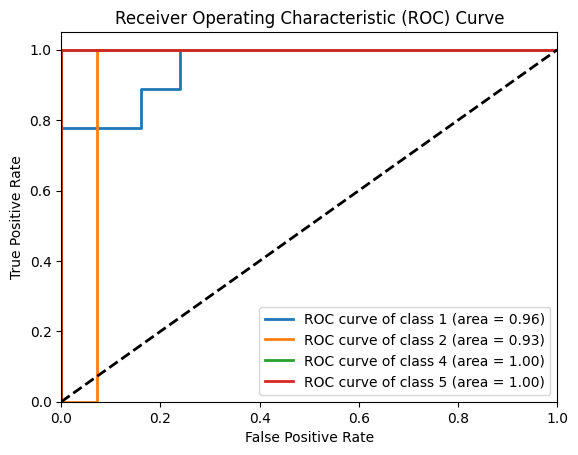

In [82]:

plt.figure()
for i in unique_classes:
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [85]:
# Predict the confidence categories for the entries labeled as category 3
category_3_data =combined_data[combined_data['confidence'] == "3) Uncertain significance"]
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
X_category_3 = category_3_data[numeric_columns]

# Make predictions for category 3 data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)
combined_data.loc[combined_data['confidence'] == "3) Uncertain significance", 'predicted_confidence'] = category_3_data['predicted_confidence']

/tmp/ipykernel_3935374/1694680787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/tmp/ipykernel_3935374/1694680787.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data['predicted_confidence'] = rf_classifier.

In [87]:
combined_data['predicted_confidence'].value_counts()

predicted_confidence
1.0    457
4.0    209
5.0     14
Name: count, dtype: int64